In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# تحسين إعدادات العرض
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")


In [3]:
income_stmt  = pd.read_csv('../data/raw/aapl_income_statement.csv')
balance_sheet   = pd.read_csv('../data/raw/aapl_balance_sheet.csv')
cash_flow   = pd.read_csv('../data/raw/aapl_cash_flow.csv')
stock_data   = pd.read_csv('../data/raw/aapl_stock_prices.csv')

In [5]:
# عرض المعلومات الأساسية
print("\n Income Statement:")
print(f"Shape: {income_stmt.shape}")
print(f"\nالأعمدة: {income_stmt.columns.tolist()}")

print("\n (Balance Sheet):")
print(f"Shape: {balance_sheet.shape}")
print(f"\nالأعمدة: {balance_sheet.columns.tolist()}")

print("\n (Cash Flow):")
print(f"Shape: {cash_flow.shape}")
print(f"\: {cash_flow.columns.tolist()}")


 Income Statement:
Shape: (5, 40)

الأعمدة: ['Unnamed: 0', 'Tax Effect Of Unusual Items', 'Tax Rate For Calcs', 'Normalized EBITDA', 'Net Income From Continuing Operation Net Minority Interest', 'Reconciled Depreciation', 'Reconciled Cost Of Revenue', 'EBITDA', 'EBIT', 'Net Interest Income', 'Interest Expense', 'Interest Income', 'Normalized Income', 'Net Income From Continuing And Discontinued Operation', 'Total Expenses', 'Total Operating Income As Reported', 'Diluted Average Shares', 'Basic Average Shares', 'Diluted EPS', 'Basic EPS', 'Diluted NI Availto Com Stockholders', 'Net Income Common Stockholders', 'Net Income', 'Net Income Including Noncontrolling Interests', 'Net Income Continuous Operations', 'Tax Provision', 'Pretax Income', 'Other Income Expense', 'Other Non Operating Income Expenses', 'Net Non Operating Interest Income Expense', 'Interest Expense Non Operating', 'Interest Income Non Operating', 'Operating Income', 'Operating Expense', 'Research And Development', 'Sell

In [6]:
# 3. تنظيف البيانات المالية
# =========================

def clean_financial_data(df, name):
    """
    تنظيف البيانات المالية
    
    Parameters:
    -----------
    df : DataFrame
        البيانات المالية الخام
    name : str
        اسم البيانات (للتتبع)
    
    Returns:
    --------
    DataFrame: البيانات المنظفة
    """
    print(f"\n🔧 تنظيف {name}...")
    
    # نقل التاريخ من الأعمدة إلى index
    if 'Date' in df.columns:
        df['Date'] = pd.to_datetime(df['Date'])
        df.set_index('Date', inplace=True)
    
    # ترتيب حسب التاريخ
    df.sort_index(inplace=True)
    
    # تحويل القيم إلى numeric (إزالة الفواصل والرموز)
    for col in df.columns:
        if df[col].dtype == 'object':
            # إزالة الفواصل والرموز غير الرقمية
            df[col] = df[col].astype(str).str.replace(',', '')
            df[col] = df[col].str.replace('$', '')
            df[col] = df[col].str.replace('(', '-')
            df[col] = df[col].str.replace(')', '')
            
            # التحويل إلى numeric مع التعامل مع الأخطاء
            df[col] = pd.to_numeric(df[col], errors='coerce')
    
    # تحويل المليارات لمليارات (تسهيل القراءة)
    df = df / 1e9  # تحويل للأرقام العادية
    
    print(f"✅ بعد التنظيف: {df.shape}")
    print(f"📅 الفترة: {df.index.min()} إلى {df.index.max()}")
    
    return df

# تنظيف البيانات
income_stmt_clean = clean_financial_data(income_stmt, "قائمة الدخل")
balance_sheet_clean = clean_financial_data(balance_sheet, "الميزانية العمومية")
cash_flow_clean = clean_financial_data(cash_flow, "قائمة التدفقات النقدية")

# عرض أول 5 صفوف من كل جدول
print("\n📊 قائمة الدخل (أول 5 سنوات):")
display(income_stmt_clean.head())

print("\n📊 الميزانية العمومية (أول 5 سنوات):")
display(balance_sheet_clean.head())

print("\n📊 قائمة التدفقات النقدية (أول 5 سنوات):")
display(cash_flow_clean.head())


🔧 تنظيف قائمة الدخل...
✅ بعد التنظيف: (5, 40)
📅 الفترة: 0 إلى 4

🔧 تنظيف الميزانية العمومية...
✅ بعد التنظيف: (5, 70)
📅 الفترة: 0 إلى 4

🔧 تنظيف قائمة التدفقات النقدية...
✅ بعد التنظيف: (5, 54)
📅 الفترة: 0 إلى 4

📊 قائمة الدخل (أول 5 سنوات):


,Unnamed: 0,Tax Effect Of Unusual Items,Tax Rate For Calcs,Normalized EBITDA,Net Income From Continuing Operation Net Minority Interest,Reconciled Depreciation,Reconciled Cost Of Revenue,EBITDA,EBIT,Net Interest Income,Interest Expense,Interest Income,Normalized Income,Net Income From Continuing And Discontinued Operation,Total Expenses,Total Operating Income As Reported,Diluted Average Shares,Basic Average Shares,Diluted EPS,Basic EPS,Diluted NI Availto Com Stockholders,Net Income Common Stockholders,Net Income,Net Income Including Noncontrolling Interests,Net Income Continuous Operations,Tax Provision,Pretax Income,Other Income Expense,Other Non Operating Income Expenses,Net Non Operating Interest Income Expense,Interest Expense Non Operating,Interest Income Non Operating,Operating Income,Operating Expense,Research And Development,Selling General And Administration,Gross Profit,Cost Of Revenue,Total Revenue,Operating Revenue
0,NaN,0.0,1.560000e-10,144.748,112.010,11.698,220.960,144.748,133.050,NaN,NaN,NaN,112.010,112.010,283.111,133.050,15.004697,14.948500,7.460000e-09,7.490000e-09,112.010,112.010,112.010,112.010,112.010,20.719,132.729,-0.321,-0.321,NaN,NaN,NaN,133.050,62.151,34.550,27.601,195.201,220.960,416.161,416.161
1,NaN,0.0,2.410000e-10,134.661,93.736,11.445,210.352,134.661,123.216,NaN,NaN,NaN,93.736,93.736,267.819,123.216,15.408095,15.343783,6.080000e-09,6.110000e-09,93.736,93.736,93.736,93.736,93.736,29.749,123.485,0.269,0.269,NaN,NaN,NaN,123.216,57.467,31.370,26.097,180.683,210.352,391.035,391.035
2,NaN,0.0,1.470000e-10,125.820,96.995,11.519,214.137,125.820,114.301,-0.183,3.933,3.750,96.995,96.995,268.984,114.301,15.812547,15.744231,6.130000e-09,6.160000e-09,96.995,96.995,96.995,96.995,96.995,16.741,113.736,-0.565,-0.565,-0.183,3.933,3.750,114.301,54.847,29.915,24.932,169.148,214.137,383.285,383.285
3,NaN,0.0,1.620000e-10,130.541,99.803,11.104,223.546,130.541,119.437,-0.106,2.931,2.825,99.803,99.803,274.891,119.437,16.325819,16.215963,6.110000e-09,6.150000e-09,99.803,99.803,99.803,99.803,99.803,19.300,119.103,-0.334,-0.334,-0.106,2.931,2.825,119.437,51.345,26.251,25.094,170.782,223.546,394.328,394.328
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.198,2.645,2.843,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.198,2.645,2.843,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



📊 الميزانية العمومية (أول 5 سنوات):


,Unnamed: 0,Treasury Shares Number,Ordinary Shares Number,Share Issued,Net Debt,Total Debt,Tangible Book Value,Invested Capital,Working Capital,Net Tangible Assets,Capital Lease Obligations,Common Stock Equity,Total Capitalization,Total Equity Gross Minority Interest,Stockholders Equity,Gains Losses Not Affecting Retained Earnings,Other Equity Adjustments,Retained Earnings,Capital Stock,Common Stock,Total Liabilities Net Minority Interest,Total Non Current Liabilities Net Minority Interest,Other Non Current Liabilities,Tradeand Other Payables Non Current,Long Term Debt And Capital Lease Obligation,Long Term Capital Lease Obligation,Long Term Debt,Current Liabilities,Other Current Liabilities,Current Deferred Liabilities,Current Deferred Revenue,Current Debt And Capital Lease Obligation,Current Capital Lease Obligation,Current Debt,Other Current Borrowings,Commercial Paper,Payables And Accrued Expenses,Current Accrued Expenses,Payables,Total Tax Payable,Income Tax Payable,Accounts Payable,Total Assets,Total Non Current Assets,Other Non Current Assets,Non Current Deferred Assets,Non Current Deferred Taxes Assets,Investments And Advances,Other Investments,Investmentin Financial Assets,Available For Sale Securities,Net PPE,Accumulated Depreciation,Gross PPE,Leases,Other Properties,Machinery Furniture Equipment,Land And Improvements,Properties,Current Assets,Other Current Assets,Inventory,Receivables,Other Receivables,Accounts Receivable,Cash Cash Equivalents And Short Term Investments,Other Short Term Investments,Cash And Cash Equivalents,Cash Equivalents,Cash Financial
0,NaN,NaN,14.773260,14.773260,62.723,98.657,73.733,172.390,-17.674,73.733,NaN,73.733,152.061,73.733,73.733,-5.571,-5.571,-14.264,93.568,93.568,285.508,119.877,41.549,NaN,78.328,NaN,78.328,165.631,44.452,9.055,9.055,20.329,NaN,20.329,12.350,7.979,91.795,8.919,82.876,13.016,13.016,69.860,359.241,211.284,62.950,20.777,20.777,77.723,NaN,77.723,77.723,49.834,-76.014,125.848,15.091,NaN,83.420,27.337,0.0,147.957,14.585,5.718,72.957,33.180,39.777,54.697,18.763,35.934,7.667,28.267
1,NaN,NaN,15.116786,15.116786,76.686,106.629,56.950,163.579,-23.405,56.950,NaN,56.950,142.700,56.950,56.950,-7.172,-7.172,-19.154,83.276,83.276,308.030,131.638,45.888,9.254,85.750,NaN,85.750,176.392,44.024,8.249,8.249,20.879,NaN,20.879,10.912,9.967,103.240,NaN,95.561,26.601,26.601,68.960,364.980,211.993,55.335,19.499,19.499,91.479,NaN,91.479,91.479,45.680,-73.448,119.128,14.233,NaN,80.205,24.690,0.0,152.987,14.287,7.286,66.243,32.833,33.410,65.171,35.228,29.943,2.744,27.199
2,NaN,0.0,15.550061,15.550061,81.123,111.088,62.146,173.234,-1.742,62.146,12.842,62.146,157.427,62.146,62.146,-11.452,-11.452,-0.214,73.812,73.812,290.437,145.129,34.391,15.457,95.281,11.267,95.281,145.308,50.010,8.061,8.061,15.807,1.575,15.807,9.822,5.985,71.430,NaN,71.430,8.819,8.819,62.611,352.583,209.017,46.906,17.852,17.852,100.544,NaN,100.544,100.544,43.715,-70.884,114.599,12.839,10.661,78.314,23.446,0.0,143.566,14.695,6.331,60.985,31.477,29.508,61.555,31.590,29.965,1.606,28.359
3,NaN,NaN,15.943425,15.943425,96.423,132.480,50.672,170.741,-18.577,50.672,12.411,50.672,149.631,50.672,50.672,-11.109,-11.109,-3.068,64.849,64.849,302.083,148.101,21.737,16.657,109.707,10.748,98.959,153.982,52.630,7.912,7.912,22.773,1.663,21.110,11.128,9.982,70.667,NaN,70.667,6.552,6.552,64.115,352.755,217.350,39.053,15.375,15.375,120.805,120.805,120.805,120.805,42.117,-72.340,114.457,11.271,10.417,81.060,22.126,0.0,135.405,21.223,4.946,60.932,32.748,28.184,48.304,24.658,23.646,5.100,18.546
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.803,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,24.689,NaN,10.275,NaN,NaN,NaN,NaN,NaN,NaN,1.528,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,127.877,NaN,NaN,NaN,NaN,NaN,NaN,10.087,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



📊 قائمة التدفقات النقدية (أول 5 سنوات):


,Unnamed: 0,Free Cash Flow,Repurchase Of Capital Stock,Repayment Of Debt,Issuance Of Debt,Issuance Of Capital Stock,Capital Expenditure,Interest Paid Supplemental Data,Income Tax Paid Supplemental Data,End Cash Position,Beginning Cash Position,Changes In Cash,Financing Cash Flow,Cash Flow From Continuing Financing Activities,Net Other Financing Charges,Cash Dividends Paid,Common Stock Dividend Paid,Net Common Stock Issuance,Common Stock Payments,Common Stock Issuance,Net Issuance Payments Of Debt,Net Short Term Debt Issuance,Net Long Term Debt Issuance,Long Term Debt Payments,Long Term Debt Issuance,Investing Cash Flow,Cash Flow From Continuing Investing Activities,Net Other Investing Changes,Net Investment Purchase And Sale,Sale Of Investment,Purchase Of Investment,Net Business Purchase And Sale,Purchase Of Business,Net PPE Purchase And Sale,Purchase Of PPE,Operating Cash Flow,Cash Flow From Continuing Operating Activities,Change In Working Capital,Change In Other Working Capital,Change In Other Current Liabilities,Change In Other Current Assets,Change In Payables And Accrued Expense,Change In Payable,Change In Account Payable,Change In Inventory,Change In Receivables,Changes In Account Receivables,Other Non Cash Items,Stock Based Compensation,Deferred Tax,Deferred Income Tax,Depreciation Amortization Depletion,Depreciation And Amortization,Net Income From Continuing Operations
0,NaN,98.767,-90.711,-10.932,4.481,NaN,-12.715,NaN,43.369,35.934,29.943,5.991,-120.686,-120.686,-6.071,-15.421,-15.421,-90.711,-90.711,NaN,-8.483,-2.032,-6.451,-10.932,4.481,15.195,15.195,-1.480,29.390,53.797,-24.407,NaN,NaN,-12.715,-12.715,111.482,111.482,-25.000,NaN,-11.076,-9.197,0.902,0.902,0.902,1.400,-7.029,-6.682,-0.089,12.863,NaN,NaN,11.698,11.698,112.010
1,NaN,108.807,-94.949,-9.958,0.000,NaN,-9.447,NaN,26.102,29.943,30.737,-0.794,-121.983,-121.983,-5.802,-15.234,-15.234,-94.949,-94.949,NaN,-5.998,3.960,-9.958,-9.958,0.000,2.935,2.935,-1.308,13.690,62.346,-48.656,NaN,NaN,-9.447,-9.447,118.254,118.254,3.651,NaN,15.552,-11.731,6.020,6.020,6.020,-1.046,-5.144,-3.788,-2.266,11.688,NaN,NaN,11.445,11.445,93.736
2,NaN,99.584,-77.550,-11.151,5.228,NaN,-10.959,3.803,18.679,30.737,24.977,5.760,-108.488,-108.488,-6.012,-15.025,-15.025,-77.550,-77.550,NaN,-9.901,-3.978,-5.923,-11.151,5.228,3.705,3.705,-1.337,16.001,45.514,-29.513,NaN,NaN,-10.959,-10.959,110.543,110.543,-6.577,NaN,3.031,-5.684,-1.889,-1.889,-1.889,-1.618,-0.417,-1.688,-2.227,10.833,NaN,NaN,11.519,11.519,96.995
3,NaN,111.443,-89.402,-9.543,5.465,NaN,-10.708,2.865,19.573,24.977,35.929,-10.952,-110.749,-110.749,-6.383,-14.841,-14.841,-89.402,-89.402,NaN,-0.123,3.955,-4.078,-9.543,5.465,-22.354,-22.354,-2.086,-9.560,67.363,-76.923,-0.306,-0.306,-10.708,-10.708,122.151,122.151,1.200,0.478,6.110,-6.499,9.448,9.448,9.448,1.484,-9.343,-1.823,1.006,9.038,0.895,0.895,11.104,11.104,99.803
4,NaN,NaN,NaN,NaN,NaN,1.105,NaN,2.687,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.105,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.033,-0.033,NaN,NaN,NaN,NaN,NaN,1.676,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-4.774,-4.774,NaN,NaN,NaN


📈 مؤشرات قائمة الدخل:
   Revenue  Gross_Profit  Operating_Income  Net_Income  Gross_Margin  \
0   416.16        195.20            133.05      112.01         46.91   
1   391.04        180.68            123.22       93.74         46.21   
2   383.28        169.15            114.30       97.00         44.13   
3   394.33        170.78            119.44       99.80         43.31   

   Operating_Margin  Net_Margin  Revenue_Growth  Net_Income_Growth  
0             31.97       26.92             NaN                NaN  
1             31.51       23.97           -6.04             -16.31  
2             29.82       25.31           -1.98               3.48  
3             30.29       25.31            2.88               2.89  


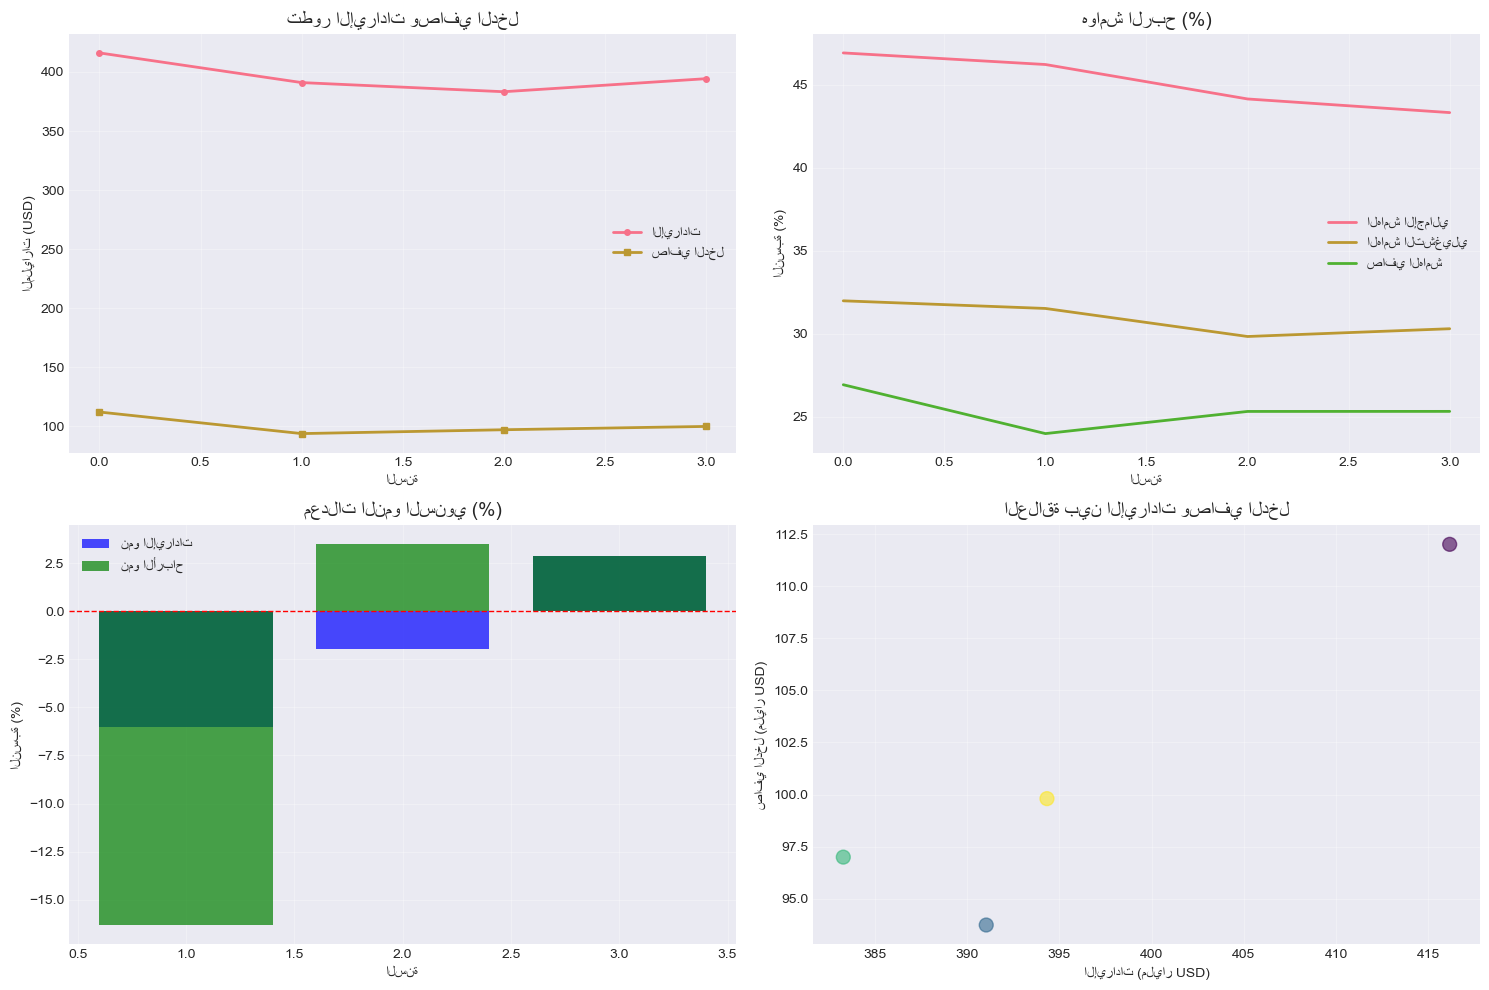


📊 أهم الإحصائيات:
متوسط الإيرادات السنوية: $396.20 مليار
متوسط صافي الدخل: $100.64 مليار
متوسط الهامش الإجمالي: 45.1%


AttributeError: 'numpy.int64' object has no attribute 'year'

In [7]:
# 4. تحليل قائمة الدخل (Income Statement Analysis)
# ================================================

"""
قائمة الدخل تظهر:
- الإيرادات (Revenue): المبيعات
- تكلفة المبيعات (Cost of Revenue): تكلفة إنتاج المنتجات
- المصروفات التشغيلية (Operating Expenses): مصاريف الإدارة والتسويق
- صافي الدخل (Net Income): الربح بعد كل المصاريف
"""

# استخراج العناصر الرئيسية
income_metrics = pd.DataFrame({
    'Revenue': income_stmt_clean.get('Revenue', income_stmt_clean.get('Total Revenue', pd.Series())),
    'Gross_Profit': income_stmt_clean.get('Gross Profit', income_stmt_clean.get('Gross Profit', pd.Series())),
    'Operating_Income': income_stmt_clean.get('Operating Income', income_stmt_clean.get('Operating Income', pd.Series())),
    'Net_Income': income_stmt_clean.get('Net Income', income_stmt_clean.get('Net Income', pd.Series()))
})

# إزالة الصفوف الفارغة
income_metrics = income_metrics.dropna()

# حساب الهوامش
income_metrics['Gross_Margin'] = (income_metrics['Gross_Profit'] / income_metrics['Revenue']) * 100
income_metrics['Operating_Margin'] = (income_metrics['Operating_Income'] / income_metrics['Revenue']) * 100
income_metrics['Net_Margin'] = (income_metrics['Net_Income'] / income_metrics['Revenue']) * 100

# حساب معدل النمو السنوي
income_metrics['Revenue_Growth'] = income_metrics['Revenue'].pct_change() * 100
income_metrics['Net_Income_Growth'] = income_metrics['Net_Income'].pct_change() * 100

print("📈 مؤشرات قائمة الدخل:")
print("=" * 60)
print(income_metrics.tail(10).round(2))

# رسم تطور الإيرادات والأرباح
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. الإيرادات وصافي الدخل
axes[0, 0].plot(income_metrics.index, income_metrics['Revenue'], 
                label='الإيرادات', linewidth=2, marker='o', markersize=4)
axes[0, 0].plot(income_metrics.index, income_metrics['Net_Income'], 
                label='صافي الدخل', linewidth=2, marker='s', markersize=4)
axes[0, 0].set_title('تطور الإيرادات وصافي الدخل', fontsize=14)
axes[0, 0].set_xlabel('السنة')
axes[0, 0].set_ylabel('المليارات (USD)')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. هوامش الربح
axes[0, 1].plot(income_metrics.index, income_metrics['Gross_Margin'], 
                label='الهامش الإجمالي', linewidth=2)
axes[0, 1].plot(income_metrics.index, income_metrics['Operating_Margin'], 
                label='الهامش التشغيلي', linewidth=2)
axes[0, 1].plot(income_metrics.index, income_metrics['Net_Margin'], 
                label='صافي الهامش', linewidth=2)
axes[0, 1].set_title('هوامش الربح (%)', fontsize=14)
axes[0, 1].set_xlabel('السنة')
axes[0, 1].set_ylabel('النسبة (%)')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. معدلات النمو
axes[1, 0].bar(income_metrics.index, income_metrics['Revenue_Growth'], 
               alpha=0.7, label='نمو الإيرادات', color='blue')
axes[1, 0].bar(income_metrics.index, income_metrics['Net_Income_Growth'], 
               alpha=0.7, label='نمو الأرباح', color='green')
axes[1, 0].axhline(y=0, color='red', linestyle='--', linewidth=1)
axes[1, 0].set_title('معدلات النمو السنوي (%)', fontsize=14)
axes[1, 0].set_xlabel('السنة')
axes[1, 0].set_ylabel('النسبة (%)')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 4. توزيع الإيرادات والأرباح
axes[1, 1].scatter(income_metrics['Revenue'], income_metrics['Net_Income'], 
                   alpha=0.6, s=100, c=range(len(income_metrics)), cmap='viridis')
axes[1, 1].set_title('العلاقة بين الإيرادات وصافي الدخل', fontsize=14)
axes[1, 1].set_xlabel('الإيرادات (مليار USD)')
axes[1, 1].set_ylabel('صافي الدخل (مليار USD)')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# إحصائيات مهمة
print("\n📊 أهم الإحصائيات:")
print("=" * 60)
print(f"متوسط الإيرادات السنوية: ${income_metrics['Revenue'].mean():.2f} مليار")
print(f"متوسط صافي الدخل: ${income_metrics['Net_Income'].mean():.2f} مليار")
print(f"متوسط الهامش الإجمالي: {income_metrics['Gross_Margin'].mean():.1f}%")
print(f"أفضل سنة نمو: {income_metrics['Revenue_Growth'].max():.1f}% ({income_metrics['Revenue_Growth'].idxmax().year})")
print(f"أسوأ سنة نمو: {income_metrics['Revenue_Growth'].min():.1f}% ({income_metrics['Revenue_Growth'].idxmin().year})")

📊 مؤشرات الميزانية العمومية:
Empty DataFrame
Columns: [Total_Assets, Total_Liabilities, Total_Equity, Debt_to_Equity, Debt_to_Assets, Equity_to_Assets]
Index: []


TypeError: ufunc 'isfinite' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''

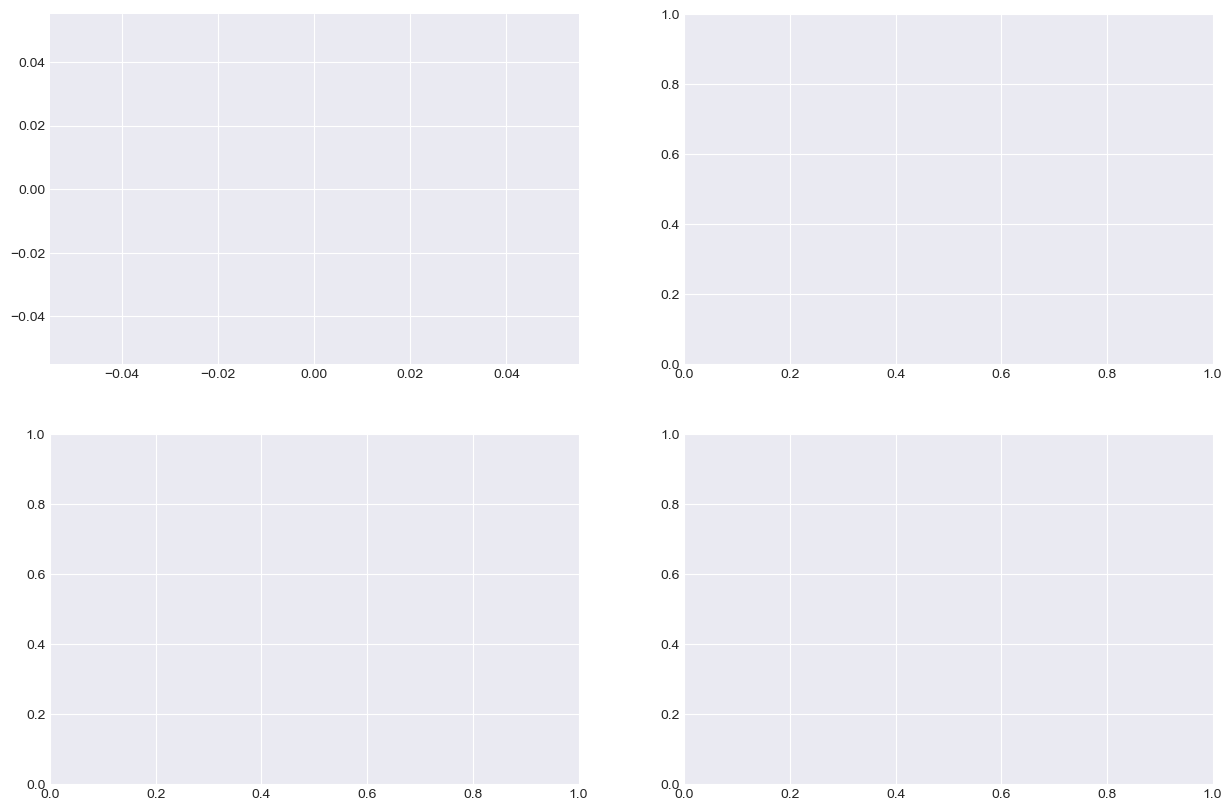

In [8]:
# 5. تحليل الميزانية العمومية (Balance Sheet Analysis)
# ====================================================

"""
الميزانية العمومية تظهر:
- الأصول (Assets): ما تملكه الشركة
- الخصوم (Liabilities): ما تدين به الشركة
- حقوق المساهمين (Equity): ما يخص المساهمين
"""

# استخراج العناصر الرئيسية
balance_metrics = pd.DataFrame({
    'Total_Assets': balance_sheet_clean.get('Total Assets', balance_sheet_clean.get('Assets', pd.Series())),
    'Total_Liabilities': balance_sheet_clean.get('Total Liabilities', balance_sheet_clean.get('Liabilities', pd.Series())),
    'Total_Equity': balance_sheet_clean.get('Total Equity', balance_sheet_clean.get('Equity', pd.Series()))
})

# إزالة الصفوف الفارغة
balance_metrics = balance_metrics.dropna()

# حساب النسب المالية
balance_metrics['Debt_to_Equity'] = balance_metrics['Total_Liabilities'] / balance_metrics['Total_Equity']
balance_metrics['Debt_to_Assets'] = (balance_metrics['Total_Liabilities'] / balance_metrics['Total_Assets']) * 100
balance_metrics['Equity_to_Assets'] = (balance_metrics['Total_Equity'] / balance_metrics['Total_Assets']) * 100

print("📊 مؤشرات الميزانية العمومية:")
print("=" * 60)
print(balance_metrics.tail(10).round(2))

# رسم هيكل الميزانية العمومية
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. الأصول مقابل الخصوم
axes[0, 0].plot(balance_metrics.index, balance_metrics['Total_Assets'], 
                label='إجمالي الأصول', linewidth=2, marker='o')
axes[0, 0].plot(balance_metrics.index, balance_metrics['Total_Liabilities'], 
                label='إجمالي الخصوم', linewidth=2, marker='s')
axes[0, 0].fill_between(balance_metrics.index, 
                         balance_metrics['Total_Assets'], 
                         balance_metrics['Total_Liabilities'],
                         alpha=0.3, label='حقوق المساهمين')
axes[0, 0].set_title('تطور الأصول والخصوم', fontsize=14)
axes[0, 0].set_xlabel('السنة')
axes[0, 0].set_ylabel('المليارات (USD)')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. نسبة الدين إلى حقوق الملكية
axes[0, 1].plot(balance_metrics.index, balance_metrics['Debt_to_Equity'], 
                color='red', linewidth=2, marker='o')
axes[0, 1].axhline(y=1, color='green', linestyle='--', label='نسبة 1:1')
axes[0, 1].fill_between(balance_metrics.index, 0, balance_metrics['Debt_to_Equity'], 
                        alpha=0.3, color='red')
axes[0, 1].set_title('نسبة الدين إلى حقوق الملكية', fontsize=14)
axes[0, 1].set_xlabel('السنة')
axes[0, 1].set_ylabel('النسبة')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. هيكل التمويل (نسبة)
axes[1, 0].stackplot(balance_metrics.index, 
                     balance_metrics['Total_Liabilities'], 
                     balance_metrics['Total_Equity'],
                     labels=['الخصوم', 'حقوق المساهمين'],
                     alpha=0.7)
axes[1, 0].set_title('هيكل التمويل (الخصوم vs حقوق المساهمين)', fontsize=14)
axes[1, 0].set_xlabel('السنة')
axes[1, 0].set_ylabel('المليارات (USD)')
axes[1, 0].legend(loc='upper left')
axes[1, 0].grid(True, alpha=0.3)

# 4. الملاءة المالية
axes[1, 1].plot(balance_metrics.index, balance_metrics['Equity_to_Assets'], 
                label='نسبة حقوق المساهمين', linewidth=2, color='green')
axes[1, 1].plot(balance_metrics.index, balance_metrics['Debt_to_Assets'], 
                label='نسبة الدين', linewidth=2, color='red')
axes[1, 1].set_title('نسب الملاءة المالية (%)', fontsize=14)
axes[1, 1].set_xlabel('السنة')
axes[1, 1].set_ylabel('النسبة (%)')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n📊 تحليل الملاءة المالية:")
print("=" * 60)
print(f"متوسط نسبة الدين إلى حقوق الملكية: {balance_metrics['Debt_to_Equity'].mean():.2f}")
print(f"أعلى نسبة دين: {balance_metrics['Debt_to_Equity'].max():.2f} ({balance_metrics['Debt_to_Equity'].idxmax().year})")
print(f"أقل نسبة دين: {balance_metrics['Debt_to_Equity'].min():.2f} ({balance_metrics['Debt_to_Equity'].idxmin().year})")